In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import h5py
import matplotlib.pyplot as plt



csv_path = Path(r"C:\Users\Lenovo\Downloads\fair_face_with_labels\fairface-label-train.csv")
img_dir = Path(r"C:\Users\Lenovo\Downloads\fair_face_with_labels\fairface-img-margin025-trainval2\train")


df = pd.read_csv(csv_path)
df = df[['file', 'gender']]

df['full_path'] = df['file'].apply(lambda x: img_dir / Path(x).name)

label = {'Male': 0, 'Female': 1}
df['gender_label'] = df['gender'].map(label)

images = df['full_path'].to_numpy()
labels = df['gender_label'].to_numpy()

tr_images, val_images, tr_labels, val_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


: 

In [3]:
class GenderDataset(Dataset):
    def __init__(self, images, labels, img_size=(128,128), device='cuda'):
        self.device = device
        self.labels = torch.tensor(labels, dtype=torch.float32, device=device)
        
        # Preload تصاویر مستقیم روی GPU
        image_tensors = []
        for p in images:
            img = Image.open(p).convert('RGB')
            img = img.resize(img_size)
            img = np.array(img, dtype=np.float32)/255.0
            img = torch.tensor(img).permute(2,0,1)  # C,H,W
            image_tensors.append(img)
        
        self.images = torch.stack(image_tensors).to(device)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

    def __len__(self):
        return len(self.labels)

# استفاده:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_dataset = GenderDataset(tr_images, tr_labels, device=device)
val_dataset   = GenderDataset(val_images, val_labels, device=device)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)


KeyboardInterrupt: 

In [15]:
class GenderDataset(Dataset):
    def __init__(self, images, labels, img_size=128):
        self.images = images
        self.labels = labels 
        self.img_size = img_size

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        img = img.resize((self.img_size, self.img_size))
        img = np.array(img, dtype=np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

    def __len__(self):
        return len(self.images)
    
train_dataset = GenderDataset(tr_images, tr_labels , img_size=128)
val_dataset   = GenderDataset(val_images, val_labels , img_size=128)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

model = nn.Sequential(
    nn.Conv2d(3 , 32 , kernel_size=3),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32 , 64 , kernel_size=3),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(64 , 128,kernel_size=3),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128*14*14 , 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512 , 1),
    nn.Sigmoid()
).to(device)

loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)



Epoch 1/10, Train Loss: 0.8459, Validation Loss: 0.4797, Train Accuracy: 0.6605, Validation Accuracy: 0.7490
Epoch 2/10, Train Loss: 0.4611, Validation Loss: 0.4060, Train Accuracy: 0.7673, Validation Accuracy: 0.7975
Epoch 3/10, Train Loss: 0.3998, Validation Loss: 0.3732, Train Accuracy: 0.8030, Validation Accuracy: 0.8159
Epoch 4/10, Train Loss: 0.3569, Validation Loss: 0.3685, Train Accuracy: 0.8300, Validation Accuracy: 0.8273
Epoch 5/10, Train Loss: 0.3294, Validation Loss: 0.3342, Train Accuracy: 0.8438, Validation Accuracy: 0.8397
Epoch 6/10, Train Loss: 0.3042, Validation Loss: 0.3266, Train Accuracy: 0.8576, Validation Accuracy: 0.8437
Epoch 7/10, Train Loss: 0.2843, Validation Loss: 0.3367, Train Accuracy: 0.8655, Validation Accuracy: 0.8474
Epoch 8/10, Train Loss: 0.2632, Validation Loss: 0.3378, Train Accuracy: 0.8776, Validation Accuracy: 0.8386
Epoch 9/10, Train Loss: 0.2389, Validation Loss: 0.3158, Train Accuracy: 0.8890, Validation Accuracy: 0.8588
Epoch 10/10, Train 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23724\1255230629.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in  plt.gca().get_yticks()])


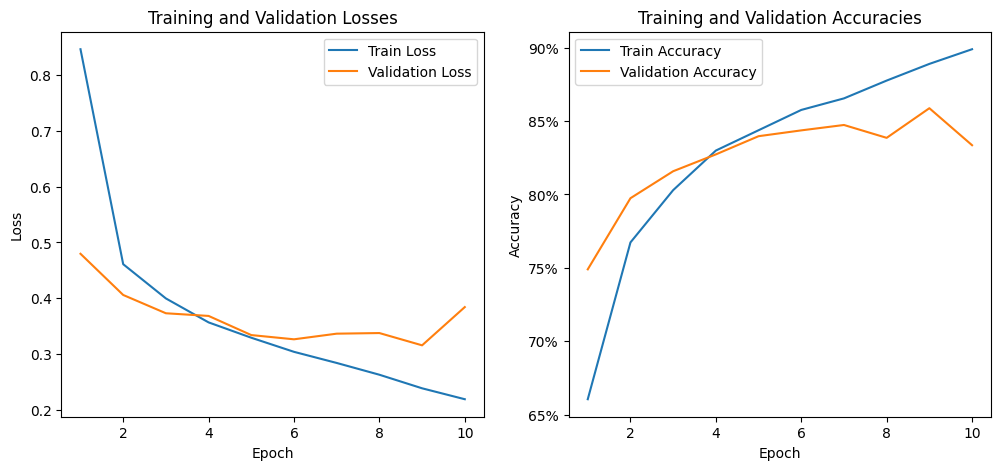

In [16]:
def accuracy(outputs , labels):
    predictions = (outputs > 0.5).float()
    correct = (predictions == labels.view(-1,1)).sum().item()
    return correct / labels.size(0)

def train(model, dataloader, optimizer,criterion):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    for inputs, labels in dataloader:
        optimizer.zero_grad()
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        labels = labels.view(-1, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += accuracy(outputs, labels)
    return total_loss / len(dataloader), total_acc / len(dataloader)
def validate(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels= inputs.to(device), labels.to(device)
            outputs = model(inputs)
            labels = labels.view(-1,1) 
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            total_acc += accuracy(outputs, labels)
    return total_loss / len(dataloader), total_acc / len(dataloader)

n_epochs = 10
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []
for epoch in range(n_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, loss_fn)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    test_loss, test_acc = validate(model, val_loader, loss_fn)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {test_loss:.4f}, "
          f"Train Accuracy: {train_acc:.4f}, Validation Accuracy: {test_acc:.4f}")

# Plot losses
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, n_epochs + 1), test_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()

# Plot accuracies
plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, n_epochs + 1), test_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracies')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in  plt.gca().get_yticks()])
plt.legend()

plt.show()

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = (outputs.squeeze() > 0.5).float()
        
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

y_pred = torch.cat(all_preds).numpy().astype(int)
y_true = torch.cat(all_labels).numpy().astype(int)

print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_true, y_pred, zero_division=0):.4f}")

Precision: 0.8825
Recall: 0.7453
F1-Score: 0.8081
